In [ ]:
dataset = "/content/drive/MyDrive/CDAC_Dataset/Project 1 - Weather Dataset.csv"

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
import warnings

# Ignore warnings for cleaner output
warnings.filterwarnings("ignore")

# Load the dataset
df = pd.read_csv(dataset)
df.head()

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather
0,1/1/2012 0:00,-1.8,-3.9,86,4,8.0,101.24,Fog
1,1/1/2012 1:00,-1.8,-3.7,87,4,8.0,101.24,Fog
2,1/1/2012 2:00,-1.8,-3.4,89,7,4.0,101.26,"Freezing Drizzle,Fog"
3,1/1/2012 3:00,-1.5,-3.2,88,6,4.0,101.27,"Freezing Drizzle,Fog"
4,1/1/2012 4:00,-1.5,-3.3,88,7,4.8,101.23,Fog


In [ ]:
# 1. Clean the 'Weather' strings and split by comma to create dummy variables
# This creates a new dataframe where each unique weather condition is a column (0 or 1)
weather_dummies = df['Weather'].str.get_dummies(sep=',')

# 2. Join the dummies back to the main dataframe
df = pd.concat([df, weather_dummies], axis=1)

# 3. Drop the original 'Weather' column as it's now encoded
df.drop('Weather', axis=1, inplace=True)

print(f"Weather column expanded. New columns: {weather_dummies.columns.tolist()}")
df.head()

Weather column expanded. New columns: ['Blowing Snow', 'Clear', 'Cloudy', 'Drizzle', 'Fog', 'Freezing Drizzle', 'Freezing Fog', 'Freezing Rain', 'Haze', 'Heavy Rain Showers', 'Ice Pellets', 'Mainly Clear', 'Moderate Rain', 'Moderate Rain Showers', 'Moderate Snow', 'Mostly Cloudy', 'Rain', 'Rain Showers', 'Snow', 'Snow Grains', 'Snow Pellets', 'Snow Showers', 'Thunderstorms']


,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Blowing Snow,Clear,Cloudy,...,Moderate Rain Showers,Moderate Snow,Mostly Cloudy,Rain,Rain Showers,Snow,Snow Grains,Snow Pellets,Snow Showers,Thunderstorms
0,1/1/2012 0:00,-1.8,-3.9,86,4,8.0,101.24,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1/1/2012 1:00,-1.8,-3.7,87,4,8.0,101.24,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1/1/2012 2:00,-1.8,-3.4,89,7,4.0,101.26,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1/1/2012 3:00,-1.5,-3.2,88,6,4.0,101.27,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1/1/2012 4:00,-1.5,-3.3,88,7,4.8,101.23,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Convert Date/Time to datetime and set as index
df['Date/Time'] = pd.to_datetime(df['Date/Time'])
df.set_index('Date/Time', inplace=True)

# Ensure the frequency is hourly (as per the dataset)
df = df.asfreq('H')

# Fill any missing values created by frequency setting (if any)
df = df.fillna(method='ffill')

print("Time-series index set.")

Time-series index set.


In [ ]:
# Define target (y) and exogenous features (X)
y = df['Temp_C']
X = df.drop('Temp_C', axis=1)

# Use a subset for faster demonstration (last 500 hours)
subset_size = 500
test_size = 48

y_train, y_test = y[-subset_size:-test_size], y[-test_size:]
X_train, X_test = X[-subset_size:-test_size], X[-test_size:]

print(f"Training features shape: {X_train.shape}")

Training features shape: (452, 28)


In [ ]:
# Define the model
# order=(p,d,q) -> (5,1,0) is used here as a baseline
# exog=X_train allows the model to 'see' the other weather features
model = SARIMAX(y_train,
                exog=X_train,
                order=(5, 1, 0),
                enforce_stationarity=False,
                enforce_invertibility=False)

model_fit = model.fit(disp=False)
print("Model Training Complete.")

Model Training Complete.


In [ ]:
model_fit = model.fit(disp=True)

Test RMSE: 0.0784


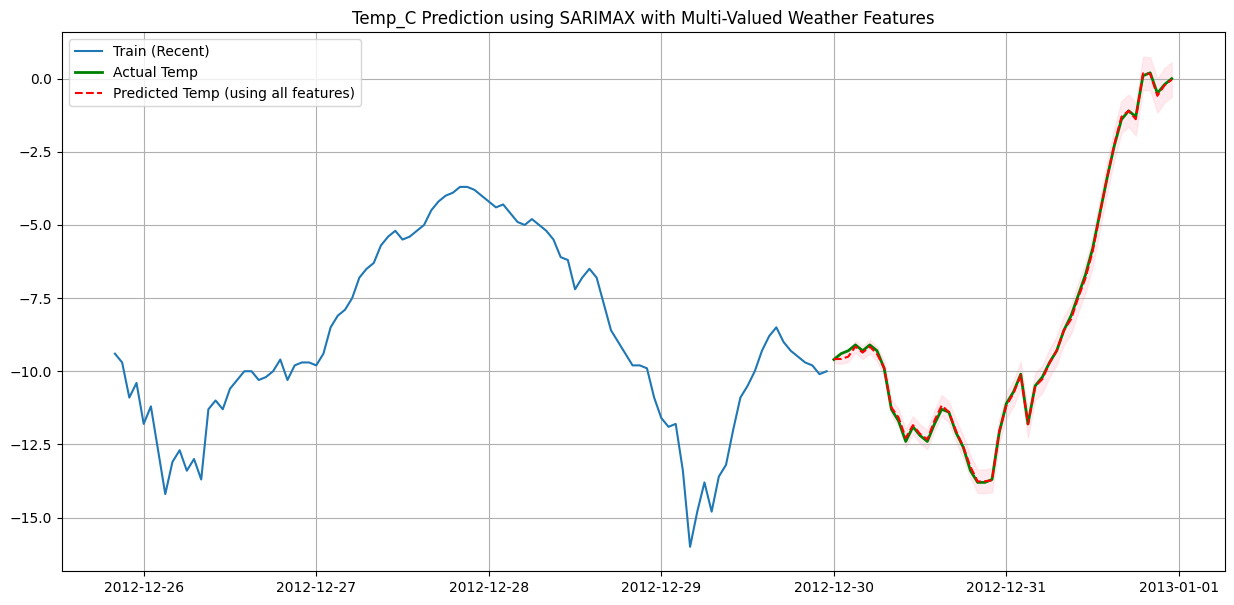

In [ ]:
# Forecast for the test period using exogenous data
forecast = model_fit.get_forecast(steps=test_size, exog=X_test)
forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test, forecast_mean))
print(f"Test RMSE: {rmse:.4f}")

# Plotting results
plt.figure(figsize=(15, 7))
plt.plot(y_train.index[-100:], y_train[-100:], label='Train (Recent)')
plt.plot(y_test.index, y_test, label='Actual Temp', color='green', linewidth=2)
plt.plot(y_test.index, forecast_mean, label='Predicted Temp (using all features)', color='red', linestyle='--')
plt.fill_between(y_test.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='pink', alpha=0.3)

plt.title('Temp_C Prediction using SARIMAX with Multi-Valued Weather Features')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import pickle
with open('weather_arima_model.pkl', 'wb') as f:
    pickle.dump(model_fit, f)

In [ ]:
with open('features.pkl', 'wb') as f:
    pickle.dump(X.columns.tolist(), f)